In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Part 1 - Basic Data Analysis

### a)

In [3]:
iris=pd.read_csv("Iris.csv")
print(f"There are {len(iris["SepalLengthCm"])} samples.")

There are 150 samples.


### b)

In [4]:
print(f"There are {len(iris.columns)} attributes:", ", ".join([name for name in iris.columns]))

There are 6 attributes: Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species


### c)

In [5]:
for attr in iris.columns:
    if (attr == "Id" or attr == "Species"): continue

    print(attr)
    print("-------------------")
    print(f"Avg: {round(np.mean(iris[attr]), 3)}")
    print(f"Median: {np.median(iris[attr])}")
    print(f"Min: {min(iris[attr])}, Max: {max(iris[attr])}")
    print(f"Std deviation: {round(np.std(iris[attr]),3)}")
    print()

SepalLengthCm
-------------------
Avg: 5.843
Median: 5.8
Min: 4.3, Max: 7.9
Std deviation: 0.825

SepalWidthCm
-------------------
Avg: 3.054
Median: 3.0
Min: 2.0, Max: 4.4
Std deviation: 0.432

PetalLengthCm
-------------------
Avg: 3.759
Median: 4.35
Min: 1.0, Max: 6.9
Std deviation: 1.759

PetalWidthCm
-------------------
Avg: 1.199
Median: 1.3
Min: 0.1, Max: 2.5
Std deviation: 0.761



### d)

In [6]:
unique_names = set(iris["Species"])
print("All possible output names: ",", ".join(unique_names))

All possible output names:  Iris-versicolor, Iris-virginica, Iris-setosa


# Part 2 - Plotting

### a)

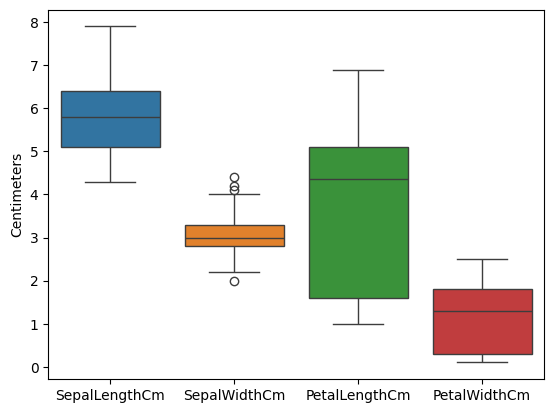

In [ ]:
iris_no_id = iris.drop("Id", axis=1)
plt.ylabel("Centimeters")
sns.boxplot(iris_no_id)
plt.show()

From the plot, we see that the attribute with the largest variance is PetalLengthCm.
We see that the attribute with the smallest variance is SepalWidthCm.

### b)

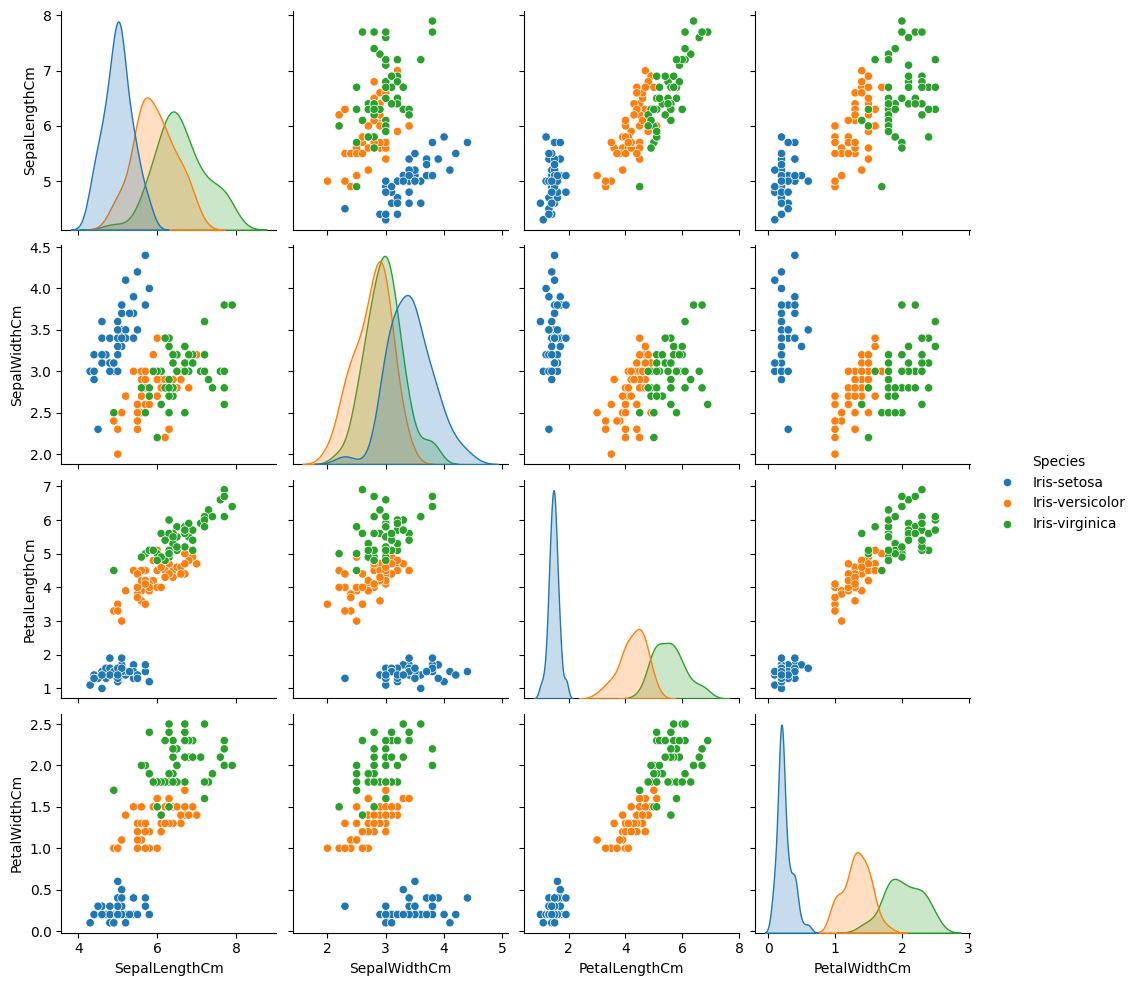

In [8]:
iris_no_id = iris.drop("Id", axis=1)
sns.pairplot(iris_no_id, hue="Species")

Looking at the univariate distribution plots in the diagonal, we can see that the variance of the Iris-setosa is smaller than for the other two species. attributes does depend on the species.
For instance, looking at the PetalLengthCm attribute, we can see that for the Iris-setosa, it doesn't have a lot of variance, however, the Iris-virginica does.

### c)

Max PetalLengthCm for the Iris-Setosa:  1.9


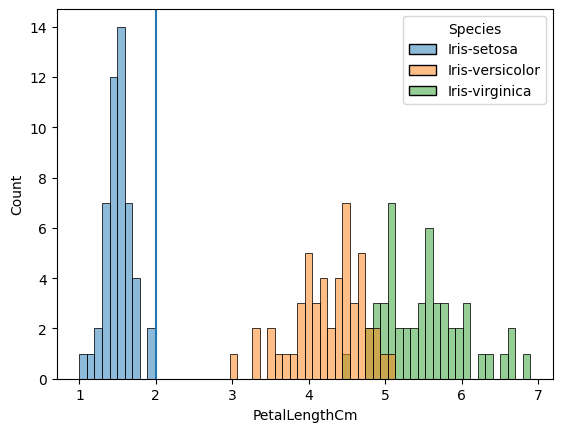

In [19]:
# Seeing where cutoff point should be
a = iris_no_id[iris_no_id["Species"] == "Iris-setosa"]
print("Max PetalLengthCm for the Iris-Setosa: ",max(a["PetalLengthCm"]))

# Rule:
""" If PetalLengthCm < 2, class = Iris-setosa, otherwise class != Iris-setosa """

sns.histplot( data=iris, x="PetalLengthCm", hue="Species", bins=60)
plt.axvline(x=2)
plt.show()

# Part 3 - The Titanic

### 3a.1, The effects of the 'Women and children first policy' on survival rate

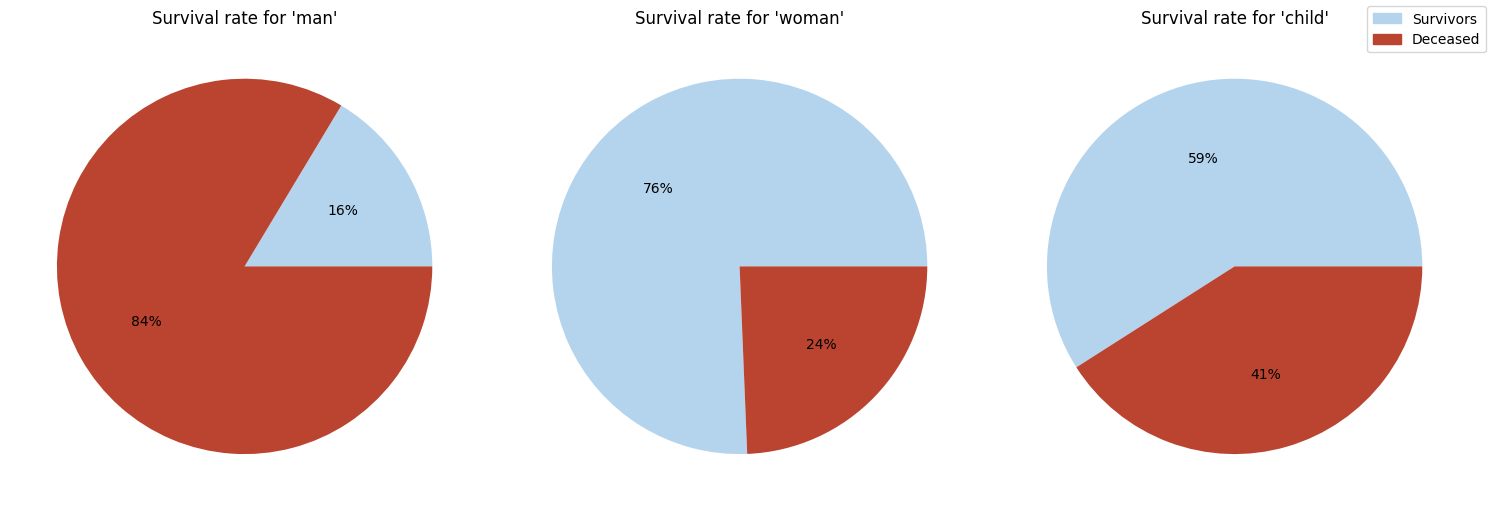

In [10]:
titanic = pd.read_csv('titanic.csv')
colors = ['#B4D4EE','#BB4430']
who_types = titanic["who"].unique()

counts_per_who:list[list[int,int]]
counts_per_who = []

for man_woman_child in who_types:
    survivors = len(titanic[(titanic["who"] == man_woman_child) & (titanic["survived"] == 1)])
    deceased = len(titanic[(titanic["who"] == man_woman_child) & (titanic["survived"] == 0)])
    counts = [survivors, deceased]
    counts_per_who.append(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(who_types)):
    axes[i].pie(counts_per_who[i], colors=colors, autopct='%.0f%%')
    axes[i].set_title(f"Survival rate for '{who_types[i]}'")

survivor_patch = mpatches.Patch(color=colors[0], label="Survivors")
deceased_patch = mpatches.Patch(color=colors[1], label="Deceased")
fig.legend(handles=[survivor_patch, deceased_patch])  

plt.tight_layout()
plt.show()

Looking at survival rates, it is clear that women and children have a much higher survival rate when compared to men (76% and 59% for women and children, versus only 16% for men).

This is strong evidence that the effect of the 'women and children first' policy was such that many more women and children survived the incident.
However, we cannot say for sure that this is due to the policy. For example, men might have partaken in more dangerous activities on the cruise, which would've driven up their death rate. But surely that cannot explain such a large gap in death rate, so the policy likely had a substanstial impact.

### 3a.2 - Class breakdowns

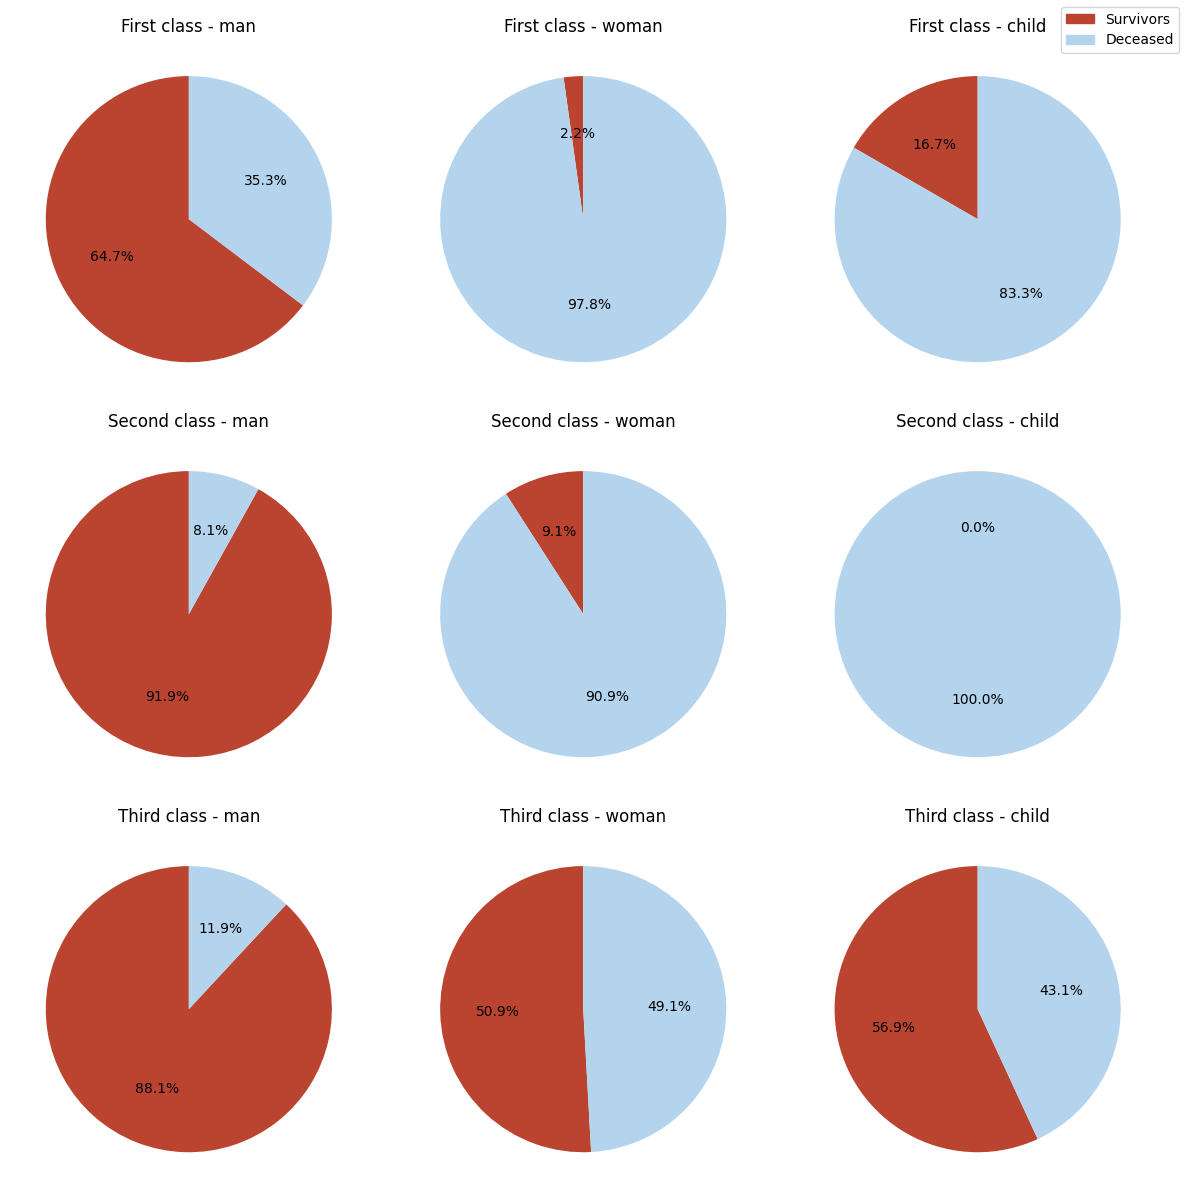

In [11]:
classes = ["First", "Second", "Third"]
who_types = titanic["who"].unique()
colors = ['#BB4430','#B4D4EE']

fig, axes = plt.subplots(len(classes), len(who_types), figsize=(12, 12))

for i, class_ in enumerate(classes):
    for j, who in enumerate(who_types):
        ax = axes[i, j]
        subset = titanic[(titanic["class"] == class_) & (titanic["who"] == who)]
        counts = subset["survived"].value_counts().reindex([0, 1], fill_value=0)
        ax.pie(
            counts,
            colors=colors,
            autopct="%1.1f%%",
            startangle=90
        )
        ax.set_title(f"{class_} class - {who}")


survivor_patch = mpatches.Patch(color=colors[0], label="Survivors")
deceased_patch = mpatches.Patch(color=colors[1], label="Deceased")
fig.legend(handles=[survivor_patch, deceased_patch])  

plt.tight_layout()
plt.show()

Here we see a series of pie charts breaking down the survival rates of Titanic passengers by class and gender/age group. Each row represents a passenger class (first, second, third), and each column represents a passenger type: man, woman, or child. The red portion of each pie chart represents survivors, while the blue portion represents deceased passengers.

We can see a clear 'L' shape where the survival rate is much lower; this 'L' includes men and passengers in third class. The lower survival rate for men is visible across all classes, emphasising the effect of the policy.
We can also see that first-class passengers generally have higher survival rates, but other factors may have contributed.

### 3b - Interesting Notes

### Note 1: The economics of towns.

We felt like looking at the different embarkment towns and what we could say about them could be interesting. Let's start by looking at survival rate.

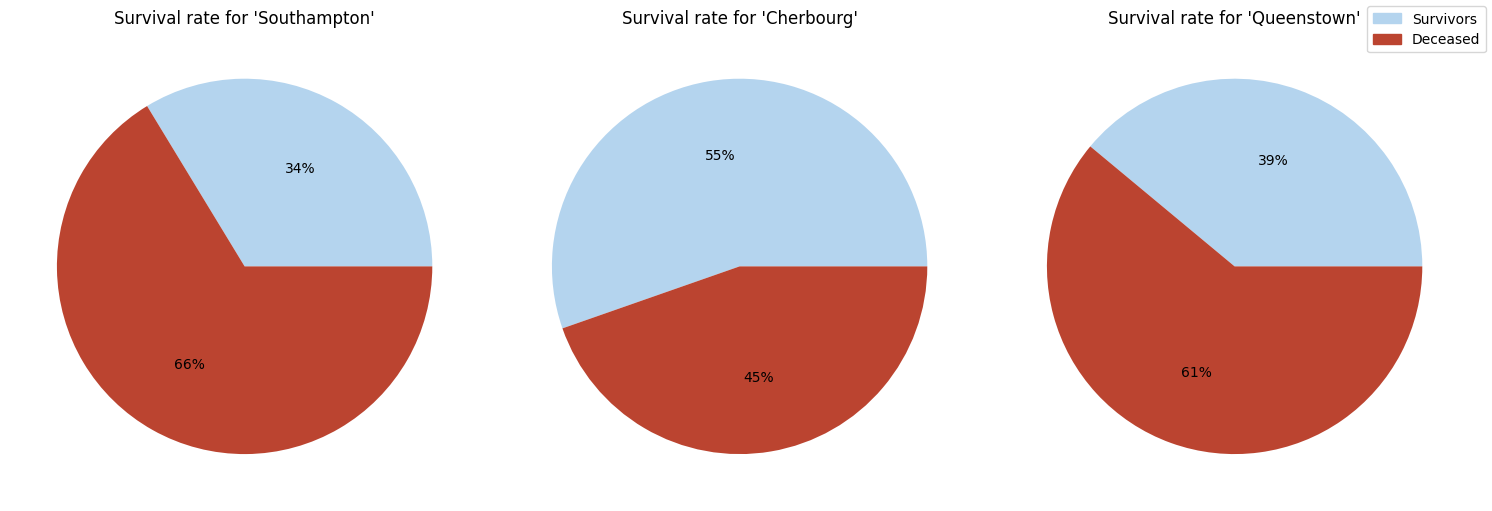

In [12]:
colors = ['#B4D4EE','#BB4430']
town_types = titanic["embark_town"].unique()

counts_per_who:list[list[int,int]]
counts_per_who = []

for town in town_types:
    survivors = len(titanic[(titanic["embark_town"] == town) & (titanic["survived"] == 1)])
    deceased = len(titanic[(titanic["embark_town"] == town) & (titanic["survived"] == 0)])
    counts = [survivors, deceased]
    counts_per_who.append(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(town_types)-1):
    axes[i].pie(counts_per_who[i], colors=colors, autopct='%.0f%%')
    axes[i].set_title(f"Survival rate for '{town_types[i]}'")

survivor_patch = mpatches.Patch(color=colors[0], label="Survivors")
deceased_patch = mpatches.Patch(color=colors[1], label="Deceased")
fig.legend(handles=[survivor_patch, deceased_patch])  

plt.tight_layout()
plt.show()

We can see that guests who embarked from Cherbour had a higher survival rate. According to previous results, this could mean that Cherbourg residents were more likely to buy Class 1 tickets. Let's examine if that holds up.

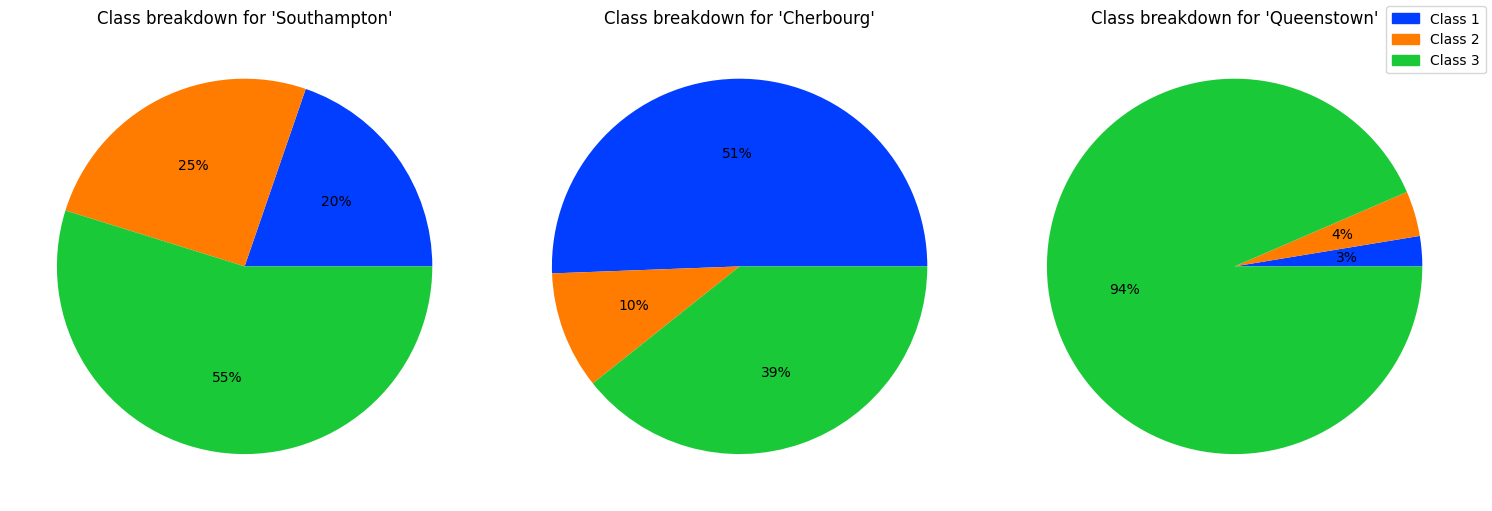

In [13]:
colors = sns.color_palette("bright")
town_types = titanic["embark_town"].unique()

counts_per_who:list[list[int,int]]
counts_per_who = []

for town in town_types:
    counts = []
    for class_ in ["First", "Second", "Third"]:
        c = len(titanic[(titanic["embark_town"] == town) & (titanic["class"] == class_)])
        counts.append(c)
    counts_per_who.append(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(town_types)-1):
    axes[i].pie(counts_per_who[i], colors=colors, autopct='%.0f%%')
    axes[i].set_title(f"Class breakdown for '{town_types[i]}'")

c1 = mpatches.Patch(color=colors[0], label="Class 1")
c2 = mpatches.Patch(color=colors[1], label="Class 2")
c3 = mpatches.Patch(color=colors[2], label="Class 3")
fig.legend(handles=[c1, c2, c3])  

plt.tight_layout()
plt.show()


We can see that a majority of guests who embarked from Cherbourg did in fact have Class 1 tickets!

It's usually not a good idea to make large sweeping statements from such data. But if we were forced to articulate something more from the data shown, we might suggest that, at the time, Queenstown was likely a poorer town compared to Southampton or Cherbourg.

### Note 2: Tickets and age.

We all had some intuition on that older guests would spend more on tickets, due to having more disposable income. We can fact check this intuition with a scatter plot:

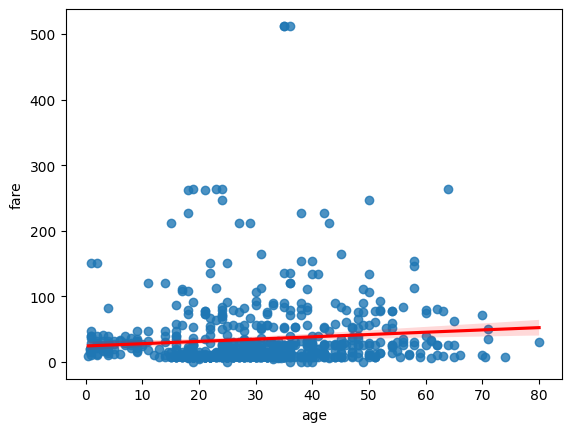

In [14]:
sns.regplot(data=titanic, x="age", y="fare", line_kws={"color":"red"})
plt.show()

We seemed to be completely wrong. The data seems mostly scattered around 1 - 75, no matter the age of guest. The guests with the highest ticket prices were only around 35. So there is not a strong correlation between age and ticket fare.